In [1]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [2]:
data_keys = ['23343-5-17',
 '23964-4-22',
 '23656-14-22',
 '21067-10-18',
 '26872-17-20',
 '22846-10-16',
 '27204-5-13']

In [3]:
def knn_cons(knn1, knn2, eps=1e-8):
    N, k = knn1.shape
    overlaps = np.empty(N, dtype=int)

    for i in range(N):
        shared = np.intersect1d(knn1[i], knn2[i])
        overlaps[i] = len(shared)

    ev = k * k / (N - 1)  # Hypergeometric distribution with m=k
    overlaps = (overlaps - ev + eps) / (k - ev + eps)  # Chance adjust

    return overlaps.mean()

In [4]:
def knn_consistency(knn1, knn2, ks, eps=1e-8):
    N = knn1.shape[0]
    ranking = np.full((N, N), N, dtype=np.int32)
    ranking[np.arange(N)[:, None], knn1] = np.arange(N - 1)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        ev = k * k / (N - 1)  # Hypergeometric distribution with m=k
        overlap = (num_shared - ev + eps) / (k - ev + eps)  # Chance adjust
        overlaps.append(overlap)

    return np.array(overlaps)

In [5]:
X1 = np.random.rand(100, 64)
X2 = np.random.rand(100, 64)

k = 99

nn1 = NearestNeighbors(n_neighbors=k).fit(X1)
knn1 = nn1.kneighbors(return_distance=False)
nn2 = NearestNeighbors(n_neighbors=k).fit(X2)
knn2 = nn2.kneighbors(return_distance=False)

knn_consistency(knn1, knn2, [98])

array([-0.01020407])

In [6]:
import pickle
with open('all_features.pkl', 'rb') as f:
    all_features = pickle.load(f)

In [7]:
N = all_features[0]['base'].shape[0]

In [8]:
nn = NearestNeighbors(n_neighbors=N-1).fit(all_features[0]['base'])
knn = nn.kneighbors(return_distance=False)        

In [ ]:
k_range = np.unique(np.geomspace(1, int(N * 0.8), num=20, dtype=int))

consistencies_dict = {}

for model_type in all_features[0].keys():
    if model_type != 'base': continue
    
    knns = []
    for i in [0, 1, 2]:
        print(i)
        features = all_features[i][model_type]
        nn = NearestNeighbors(n_neighbors=N-1).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    '''
    curve = []
    for k in k_range:
        print(k)
        consistency = (
            knn_cons(knns[0][:, :k], knns[1][:, :k])
            + knn_cons(knns[0][:, :k], knns[2][:, :k])
            + knn_cons(knns[1][:, :k], knns[2][:, :k])
        ) / 3
        curve.append(consistency)

    consistencies_dict[model_type] = curve
    '''

    avg_curve = (
        knn_consistency(knns[0], knns[1], ks=k_range)
        + knn_consistency(knns[0], knns[2], ks=k_range)
        + knn_consistency(knns[1], knns[2], ks=k_range)
    ) / 3

    consistencies_dict[model_type] = avg_curve

0
1
2


In [12]:
k_range

array([    1,     3,     5,     9,    17,    31,    55,    98,   175,
         311,   552,   981,  1742,  3092,  5491,  9749, 17310, 30733,
       54567])

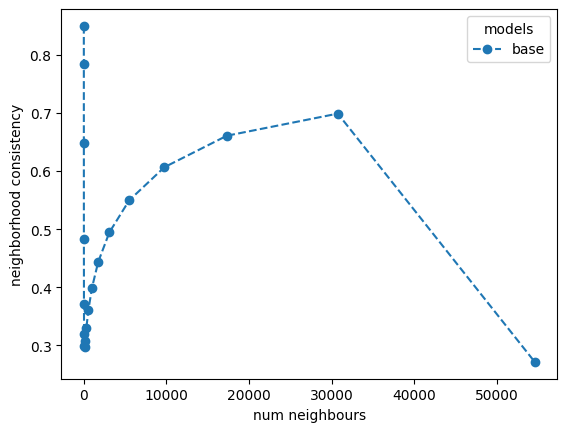

In [13]:
for model_type, curve in consistencies_dict.items():
    plt.plot(k_range, curve, ls='--', marker='o', label=model_type)

plt.xlabel('num neighbours')
plt.ylabel('neighborhood consistency')

plt.legend(title='models')
plt.show()

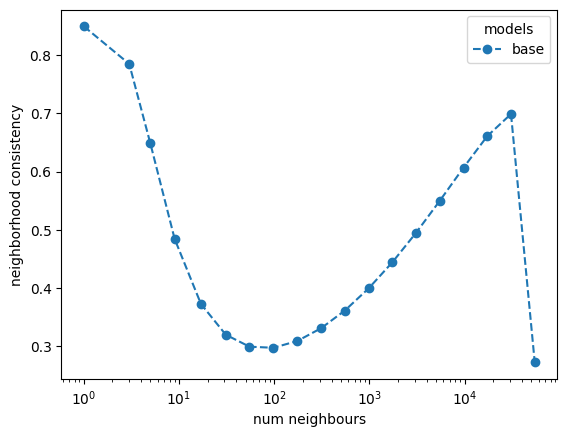

In [ ]:
for model_type, curve in consistencies_dict.items():
    plt.plot(k_range, curve, ls='--', marker='o', label=model_type)

plt.xlabel('num neighbours')
plt.ylabel('neighborhood consistency')
plt.xscale('log')
plt.legend(title='models')
plt.show()